## Assignment 03 - Deadline: Mar 18, 2026, Wed 11pm

#### DSAI 541 Spring 2026

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.bogazici.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time and no late homeworks will be accepted.


To make a pdf, this may work if you're using Jupyter notebook on browser: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu. (You can use Google Colab, but at the end you should download the ipynb notebook to submit it on Moodle.)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import HTML
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

# Problem 1: Training ANN on a dataset you choose (100 pts)

(You must use PyTorch in this problem. Answers implemented in TensorFlow will not be accepted.)

Choose a dataset of your choice, other than the Boston Housing dataset, that is suitable for a regression task.

a) Split the dataset into training, validation and test sets. Then standardize the features using StandardScaler() while avoiding data leakage.

b) Build an Artificial Neural Network (ANN) with a reasonable number of hidden layers and neurons.

c) Choose an optimizer and train your model.

d) Plot the training and validation curves. If the validation curve is still decreasing, go back to step (c) and train for more epochs. At this stage, the model should be trained for an excessively large number of epochs so that the validation curve either flattens or starts increasing. Do not stop at the optimal epoch yet; overtrain the model intentionally.

e) Based on the validation curve, determine the epoch at which training should have been stopped. For example, if the validation curve starts to flatten or increase around epoch 40, you should decide that training should have stopped at epoch 40. Do not go back and retrain yet; just identify the appropriate stopping epoch and then proceed to step (f).

f) Retrain the model "from scratch" and stop at the epoch you determined in step (e). This will be your final model. [Here "from scratch" means you should repeat the code that initializes the ANN model before training. If you don't reinitialize the model weights and train, it will not train from scratch, but it will continue training the model you did in step c)]

g) Report the training, validation and test Mean Squared Error (MSE) losses of the final model.

#### Part a)

In [2]:
# Load dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

print(f"Dataset shape: {X.shape}")
print(f"Feature names: {housing.feature_names}")
print(f"Target (MedHouseVal) range: [{y.min():.2f}, {y.max():.2f}]")

pd.set_option('display.max_rows', None)

Dataset shape: (20640, 8)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target (MedHouseVal) range: [0.15, 5.00]


In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(f"\nTensor shapes — X_train: {X_train_t.shape}, y_train: {y_train_t.shape}")

Train size: 12384
Validation size: 4128
Test size: 4128

Tensor shapes — X_train: torch.Size([12384, 8]), y_train: torch.Size([12384, 1])


#### Part b)

I will build a 3-hidden-layer ANN with ReLU activations: 8 -> 64 -> 32 -> 16 -> 1.

In [4]:
class RegressionANN(nn.Module):
    def __init__(self, input_dim):
        super(RegressionANN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train_t.shape[1]
model = RegressionANN(input_dim)
print(model)

RegressionANN(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


#### Part c)

I will use the **Adam** optimizer with a learning rate of 0.001 and MSE loss. The model is intentionally trained for a large number of epochs (500) so that overfitting becomes visible.

In [5]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 500
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training
    model.train()
    optimizer.zero_grad()
    y_pred_train = model(X_train_t)
    loss_train = criterion(y_pred_train, y_train_t)
    loss_train.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val_t)
        loss_val = criterion(y_pred_val, y_val_t)

    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}]  "
              f"Train MSE: {loss_train.item():.4f}  "
              f"Val MSE: {loss_val.item():.4f}")

Epoch [ 50/500]  Train MSE: 1.4162  Val MSE: 1.2178
Epoch [100/500]  Train MSE: 0.7203  Val MSE: 0.7119
Epoch [150/500]  Train MSE: 0.5698  Val MSE: 0.5743
Epoch [200/500]  Train MSE: 0.4608  Val MSE: 0.4743
Epoch [250/500]  Train MSE: 0.4149  Val MSE: 0.4366
Epoch [300/500]  Train MSE: 0.3924  Val MSE: 0.4185
Epoch [350/500]  Train MSE: 0.3724  Val MSE: 0.4013
Epoch [400/500]  Train MSE: 0.3560  Val MSE: 0.3885
Epoch [450/500]  Train MSE: 0.3416  Val MSE: 0.3769
Epoch [500/500]  Train MSE: 0.3281  Val MSE: 0.3663


#### Part d)

Plot the training and validation loss curves. The model was trained for 500 epochs, which is excessive enough to observe whether the validation curve flattens or increases.

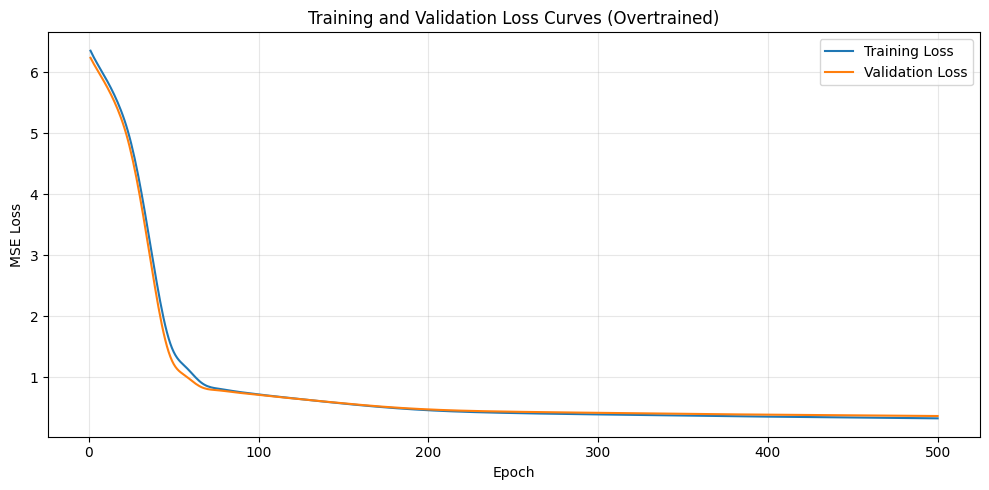

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss Curves (Overtrained)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Part e)

From the plot above, determine the epoch where validation loss is minimized (or starts to flatten/increase). I will find this programmatically as well.

Best validation MSE: 0.3663 at epoch 500

→ Training should have been stopped at approximately epoch 500.


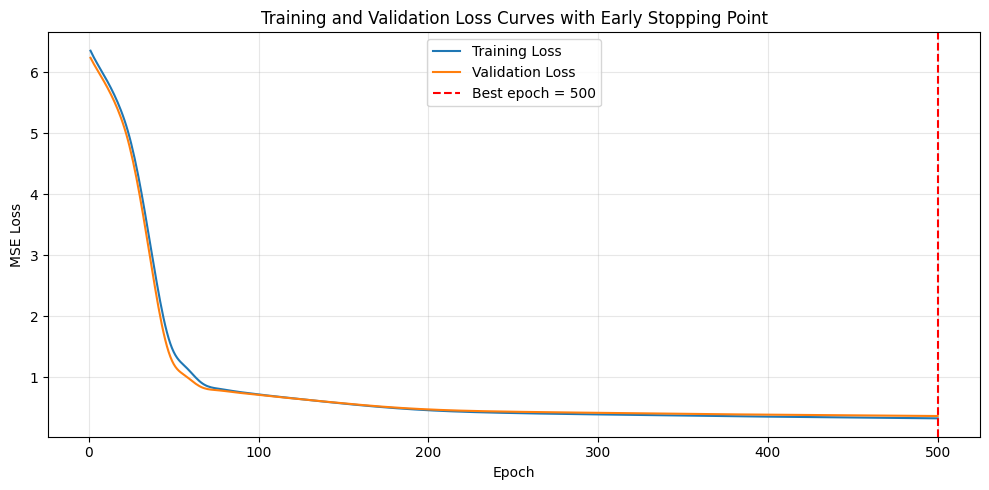

In [7]:
best_epoch = np.argmin(val_losses) + 1  # +1 because epochs are 1-indexed
best_val_loss = min(val_losses)

print(f"Best validation MSE: {best_val_loss:.4f} at epoch {best_epoch}")
print(f"\n→ Training should have been stopped at approximately epoch {best_epoch}.")

# Mark the best epoch on the plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best epoch = {best_epoch}')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss Curves with Early Stopping Point')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Part f)

Retrain the model **from scratch** (reinitialize weights) and stop at the optimal epoch determined in Part (e).

In [8]:
# Reinitialize the model from scratch
torch.manual_seed(42)
final_model = RegressionANN(input_dim)

criterion_final = nn.MSELoss()
optimizer_final = optim.Adam(final_model.parameters(), lr=0.001)

final_train_losses = []
final_val_losses = []

# Train only up to the best epoch
for epoch in range(best_epoch):
    final_model.train()
    optimizer_final.zero_grad()
    y_pred_train = final_model(X_train_t)
    loss_train = criterion_final(y_pred_train, y_train_t)
    loss_train.backward()
    optimizer_final.step()

    final_model.eval()
    with torch.no_grad():
        y_pred_val = final_model(X_val_t)
        loss_val = criterion_final(y_pred_val, y_val_t)

    final_train_losses.append(loss_train.item())
    final_val_losses.append(loss_val.item())

    if (epoch + 1) % 50 == 0 or (epoch + 1) == best_epoch:
        print(f"Epoch [{epoch+1:3d}/{best_epoch}]  "
              f"Train MSE: {loss_train.item():.4f}  "
              f"Val MSE: {loss_val.item():.4f}")

print(f"\nFinal model training complete at epoch {best_epoch}.")

Epoch [ 50/500]  Train MSE: 1.4162  Val MSE: 1.2178
Epoch [100/500]  Train MSE: 0.7203  Val MSE: 0.7119
Epoch [150/500]  Train MSE: 0.5698  Val MSE: 0.5743
Epoch [200/500]  Train MSE: 0.4608  Val MSE: 0.4743
Epoch [250/500]  Train MSE: 0.4149  Val MSE: 0.4366
Epoch [300/500]  Train MSE: 0.3924  Val MSE: 0.4185
Epoch [350/500]  Train MSE: 0.3724  Val MSE: 0.4013
Epoch [400/500]  Train MSE: 0.3560  Val MSE: 0.3885
Epoch [450/500]  Train MSE: 0.3416  Val MSE: 0.3769
Epoch [500/500]  Train MSE: 0.3281  Val MSE: 0.3663

Final model training complete at epoch 500.


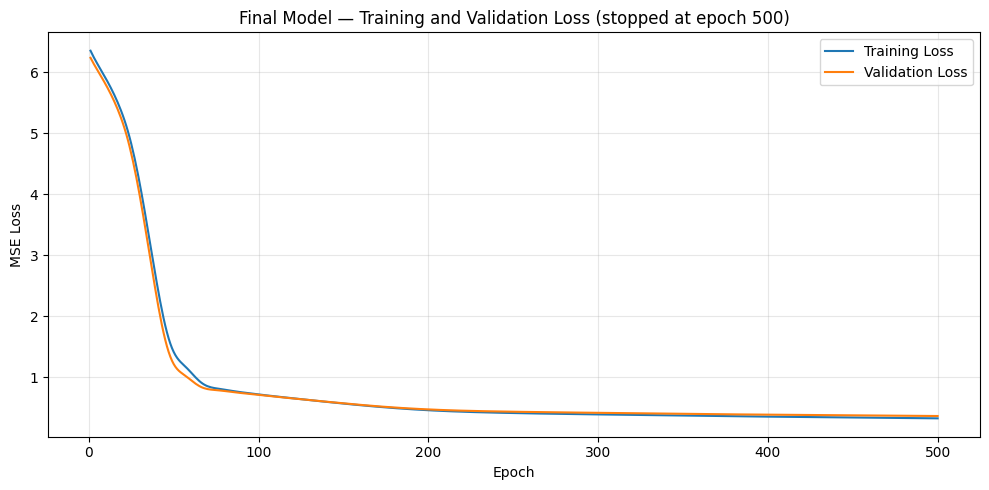

In [9]:
# Plot the final model's training curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, best_epoch + 1), final_train_losses, label='Training Loss')
plt.plot(range(1, best_epoch + 1), final_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title(f'Final Model — Training and Validation Loss (stopped at epoch {best_epoch})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Part g)

Report the training, validation and test MSE losses of the final model.

In [10]:
final_model.eval()
with torch.no_grad():
    mse_train = criterion_final(final_model(X_train_t), y_train_t).item()
    mse_val   = criterion_final(final_model(X_val_t), y_val_t).item()
    mse_test  = criterion_final(final_model(X_test_t), y_test_t).item()

print("=" * 45)
print("  Final Model — Mean Squared Error (MSE)")
print("=" * 45)
print(f"  Training MSE   : {mse_train:.4f}")
print(f"  Validation MSE : {mse_val:.4f}")
print(f"  Test MSE       : {mse_test:.4f}")
print("=" * 45)

  Final Model — Mean Squared Error (MSE)
  Training MSE   : 0.3278
  Validation MSE : 0.3663
  Test MSE       : 0.3484
